<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
### Zadanie 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import (KMeans , AgglomerativeClustering)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import (dendrogram , cut_tree, linkage)
!pip install ISLP
from ISLP.cluster import compute_linkage
from statsmodels.datasets import get_rdataset

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=e385c3fd9fd8eed0da18fd22d9af486c2dea7ffbb78ccd87c52e440d280b031f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
### Zadanie 2
data= pd.read_csv("GD_dane_genetyczne.csv")
geny = data.iloc[:,0].tolist()
ekspresja = data.iloc[:,1:].to_numpy()
czas = data.columns[1:].to_numpy()
czas = list(map(float, czas))
#modyfikacja danych
np.random.seed(int(6.24*2026))
ekspresja = ekspresja + np.random.rand(614, 7) * 0.1 - 0.05

data

,-,0,9.5,11.5,13.5,15.5,18.5,20.5
0,SS DNA,-0.131,1.699,-0.026,0.365,-0.246,0.478,0.435
1,YAL003W,0.305,0.146,-0.129,-0.444,-0.707,-1.499,-1.935
2,YAL012W,0.157,0.175,0.467,-0.379,-0.520,-1.279,-2.125
3,YAL026C,0.246,0.796,0.384,0.981,1.020,1.646,1.157
4,YAL034C,-0.235,0.487,-0.184,-0.669,-1.006,2.369,2.611
...,...,...,...,...,...,...,...,...
609,YPR136C,0.158,-0.130,-0.880,-0.693,-1.020,-2.387,-1.009
610,YPR150W,-0.306,-0.446,-0.359,0.021,0.148,1.619,1.674
611,YPR156C,0.074,0.535,1.603,1.461,1.580,0.933,2.044
612,YPR184W,-0.195,0.165,-0.333,0.421,0.858,1.633,3.028


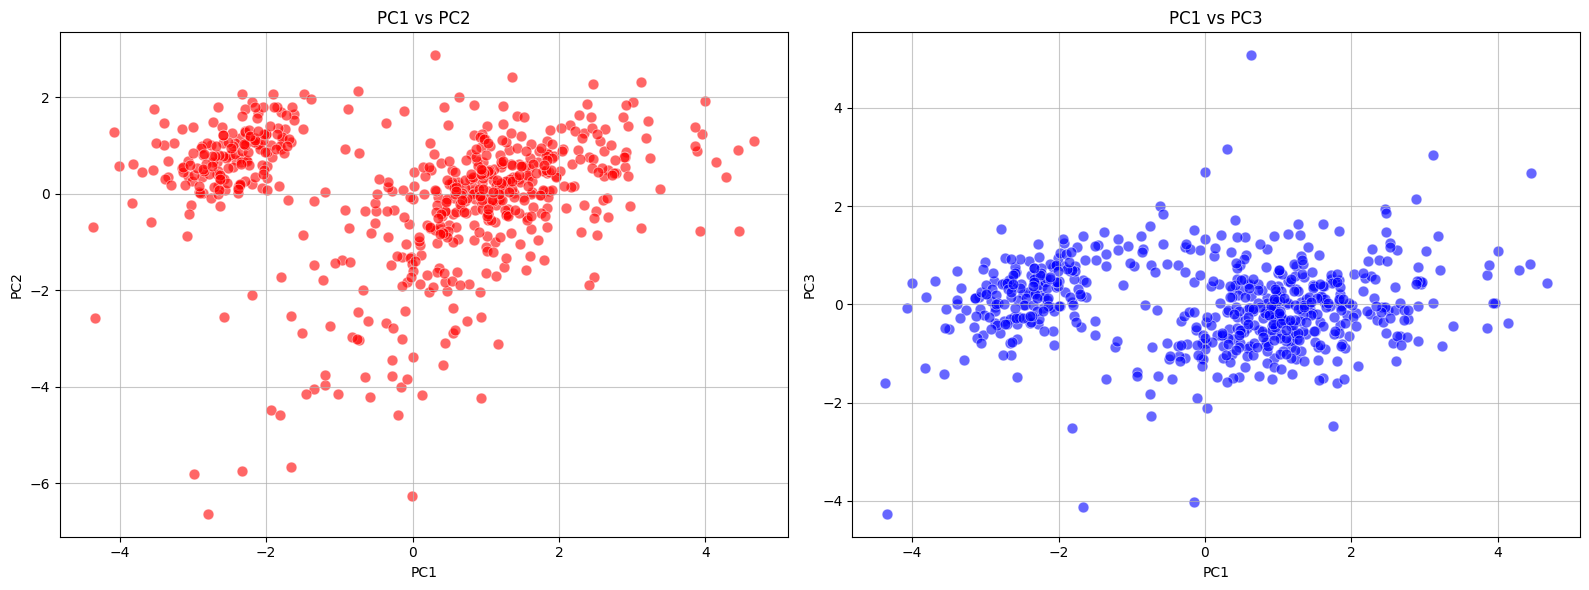

/tmp/ipykernel_2187/2889789321.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


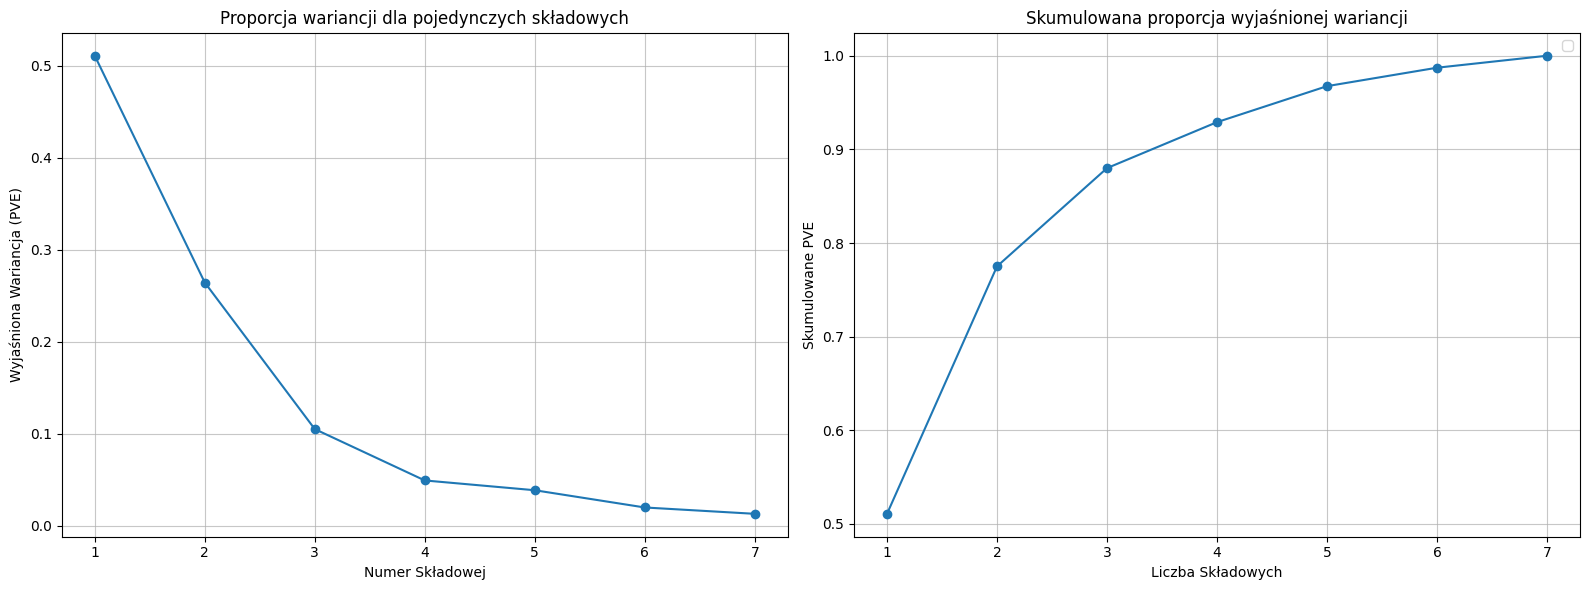

In [4]:
### Zadanie 3
scaler = StandardScaler()
ekspresja_scaled = scaler.fit_transform(ekspresja)
pca = PCA()
scores = pca.fit_transform(ekspresja_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(scores[:,0], scores[:,1], marker='o', c='red', s=60, alpha=0.6, edgecolors='white', linewidth=0.5)
ax.set_title('PC1 vs PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.7)

ax = axes[1]
ax.scatter(scores[:,0], scores[:,2], marker='o', c='blue', s=60, alpha=0.6, edgecolors='white', linewidth=0.5)
ax.set_title('PC1 vs PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC3')
ax.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ticks = np.arange(pca.n_components_) + 1

ax = axes[0]
ax.plot(ticks, pca.explained_variance_ratio_, marker='o')
ax.set_title('Proporcja wariancji dla pojedynczych składowych')
ax.set_xlabel('Numer Składowej')
ax.set_ylabel('Wyjaśniona Wariancja (PVE)')
ax.set_xticks(ticks)
ax.grid(True, alpha=0.7)

ax = axes[1]
ax.plot(ticks, pca.explained_variance_ratio_.cumsum(), marker='o')
ax.set_title('Skumulowana proporcja wyjaśnionej wariancji')
ax.set_xlabel('Liczba Składowych')
ax.set_ylabel('Skumulowane PVE')
ax.set_xticks(ticks)
ax.legend()
ax.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()

In [5]:
### Zadanie 4
kmeans = KMeans(n_clusters=16, n_init=20, random_state=42).fit(ekspresja_scaled)

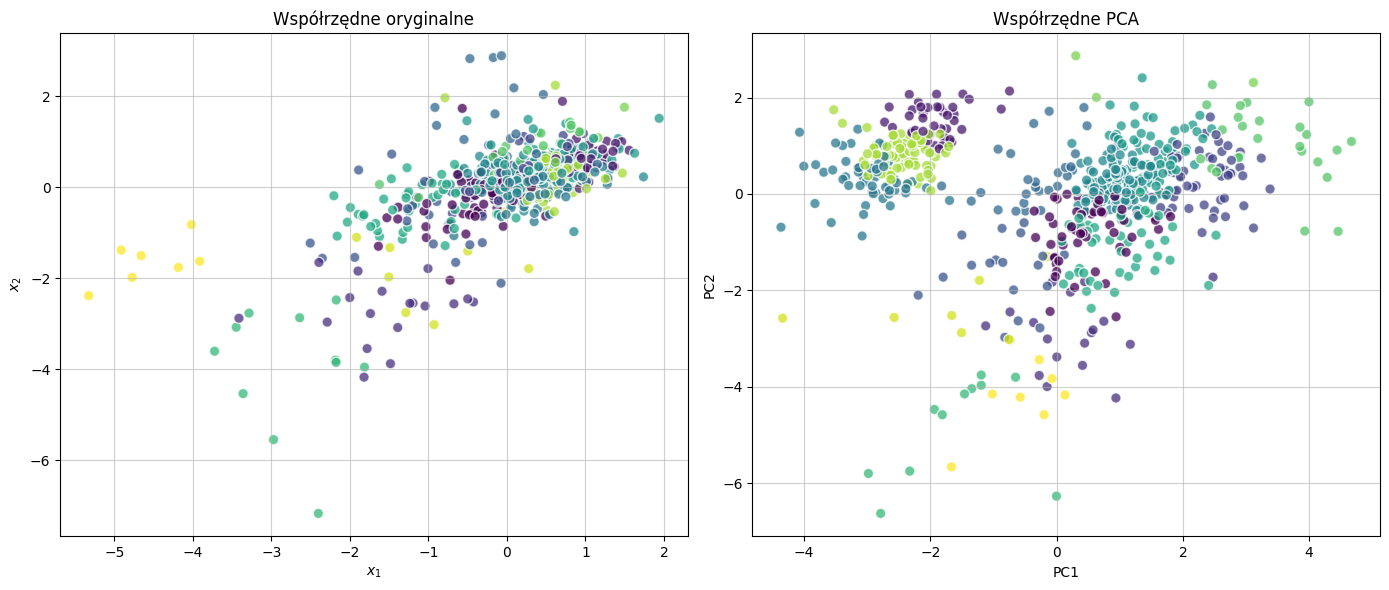

In [6]:
### Zadanie 5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
scatter1 = ax.scatter(ekspresja_scaled[:, 0], ekspresja_scaled[:, 1], c=kmeans.labels_,
                      cmap='viridis', marker='o', s=55, alpha=0.75, edgecolors='white')

ax.set_title('Współrzędne oryginalne')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.grid(True, alpha=0.6)

ax = axes[1]
scatter2 = ax.scatter(scores[:, 0], scores[:, 1], c=kmeans.labels_,
                      cmap='viridis', marker='o', s=55, alpha=0.75, edgecolors='white')

ax.set_title('Współrzędne PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True,  alpha=0.6)

plt.tight_layout()
plt.show()

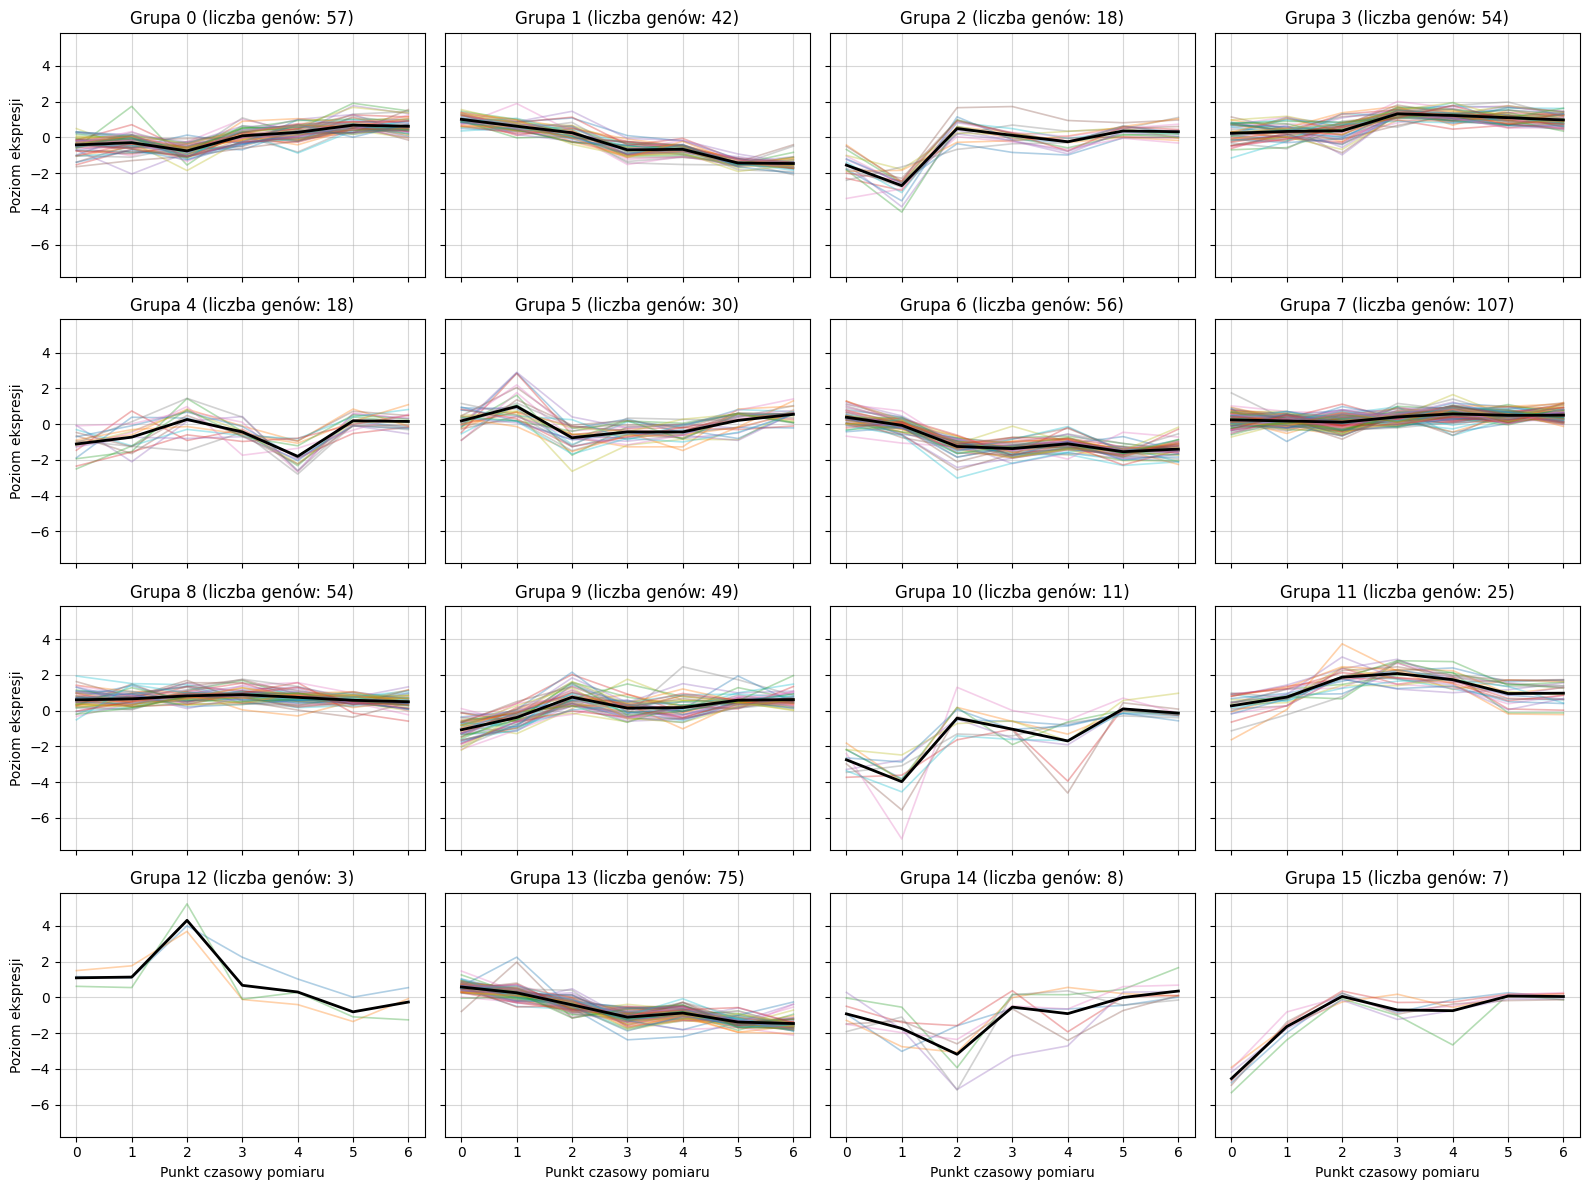

In [10]:
### Zadanie 6
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=True)
#sharex i sharey - wspólną skalę na osiach dla wszystkich wykresów

#petla po klastrach
for i, ax in enumerate(axes.flatten()):
    grupy = ekspresja_scaled[kmeans.labels_ == i]

    #petla po pojedynczych genach w klastrze
    for profil in grupy:
        ax.plot(profil, alpha=0.35, linewidth=1.2)

    centroid = kmeans.cluster_centers_[i]
    ax.plot(centroid, color='black', linewidth=2, zorder=10) # zorder rysowanie na wierzchu

    ax.set_title(f'Grupa {i} (liczba genów: {len(grupy)})')
    ax.grid(True, alpha=0.5)

    if i >= 12: # Dolny rząd
        ax.set_xlabel('Punkt czasowy pomiaru', fontsize=10)
    if i % 4 == 0: # Lewa kolumna
        ax.set_ylabel('Poziom ekspresji', fontsize=10)

plt.tight_layout()
plt.show()

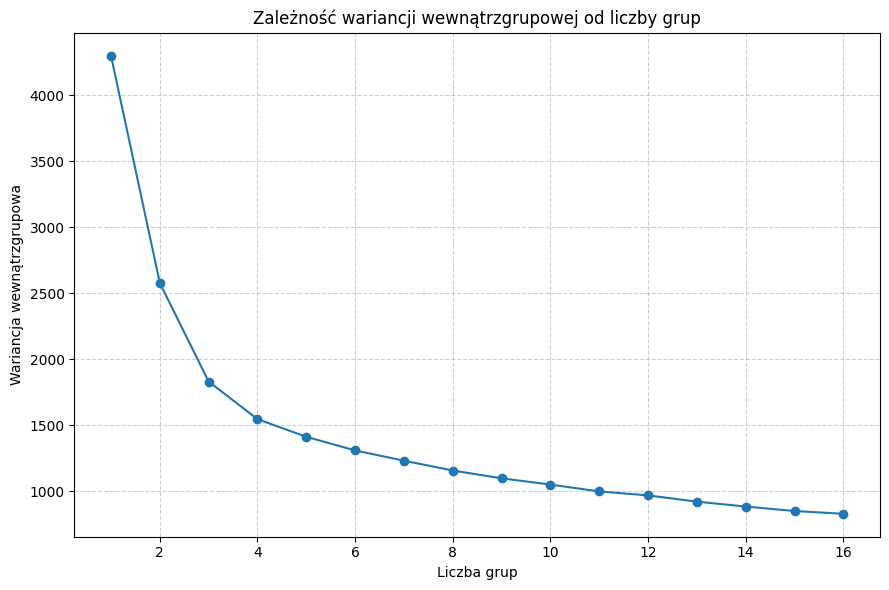

In [14]:
### Zadanie 7
plt.figure(figsize=(9, 6))

k_values = range(1, 17)
inertias_k = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(ekspresja_scaled)
    inertias_k.append(km.inertia_) #obliczenie i zachowanie wariancji

plt.plot(k_values, inertias_k, marker='o')
plt.title('Zależność wariancji wewnątrzgrupowej od liczby grup')
plt.xlabel('Liczba grup')
plt.ylabel('Wariancja wewnątrzgrupowa')

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

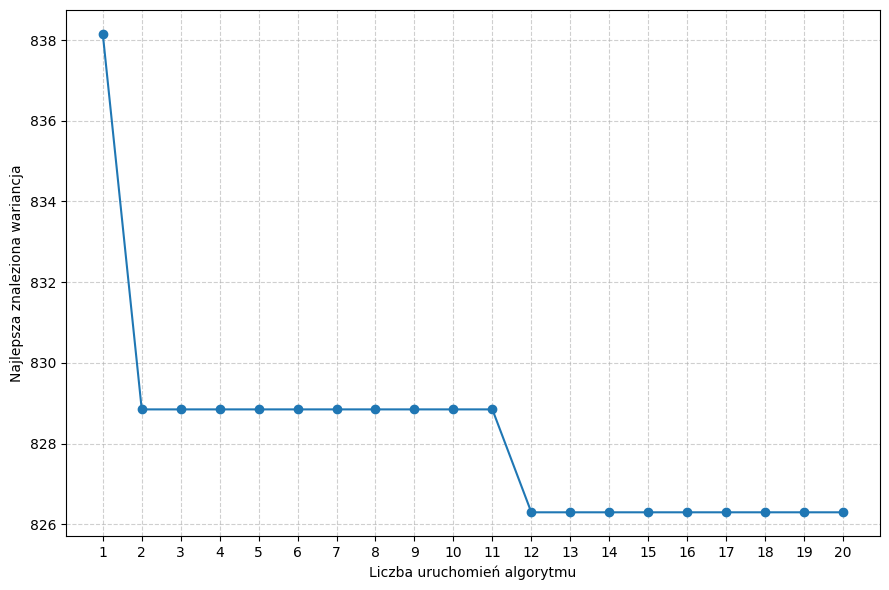

In [15]:
### Zadanie 8
plt.figure(figsize=(9, 6))

init_values = range(1, 21)
inertias_init = []

for n_init in init_values:
    km = KMeans(n_clusters=16, n_init=n_init, random_state=42)
    km.fit(ekspresja_scaled)
    inertias_init.append(km.inertia_)

plt.plot(init_values, inertias_init, marker='o')
plt.xlabel('Liczba uruchomień algorytmu')
plt.ylabel('Najlepsza znaleziona wariancja')

plt.xticks(init_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

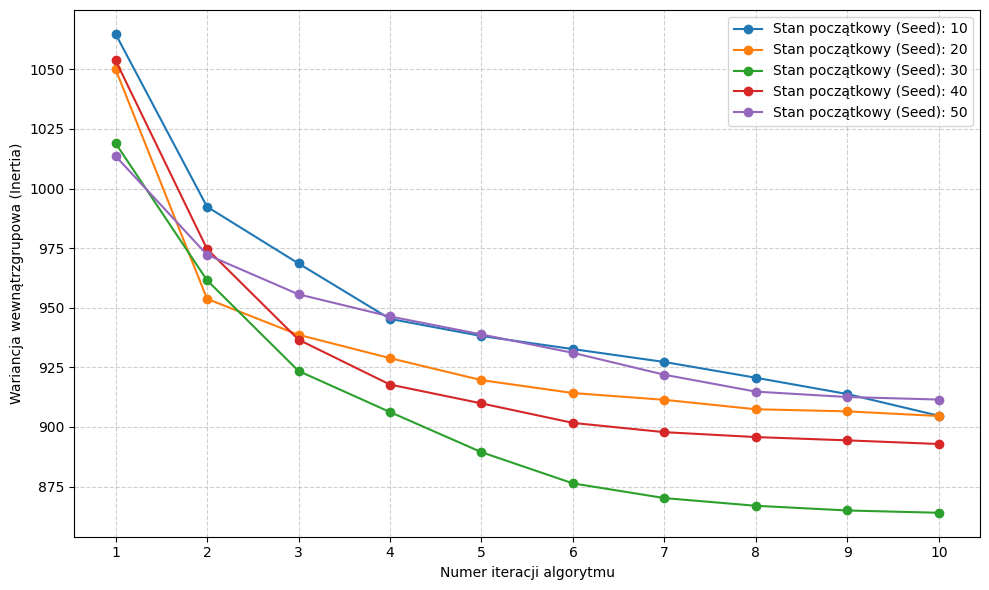

In [ ]:
### Zadanie 9
plt.figure(figsize=(10, 6))
random_states = [10, 20, 30, 40, 50]

for seed in random_states:
    inertia_history = []
    for iteracja in range(1, 11):
        km = KMeans(n_clusters=16, init='random', n_init=1, max_iter=iteracja, random_state=seed)
        km.fit(dna_scaled)
        inertia_history.append(km.inertia_)

    plt.plot(range(1, 11), inertia_history, marker='o', label=f'Stan początkowy (Seed): {seed}')

plt.xlabel('Numer iteracji algorytmu')
plt.ylabel('Wariancja wewnątrzgrupowa (Inertia)')

plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
### Zadanie 10
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0, n_clusters=None, linkage='ward')

hc_comp.fit(dna_scaled)

linkage_comp = compute_linkage(hc_comp)

In [ ]:
### Zadanie 11
cut_tree(linkage_comp, n_clusters=16).flatten()

array([ 0,  1,  1,  2,  0,  3,  2,  1,  4,  5,  4,  0,  1,  2,  6,  1,  7,
        8,  4,  4,  9,  4,  1, 10,  5, 10,  5,  0,  8,  9,  1,  9,  1,  0,
        0,  0,  1,  6,  8, 11,  4,  8,  9,  4,  9, 11,  0,  1,  6,  6,  1,
        4,  1,  2, 12, 10,  0, 13,  5, 10, 10, 10, 10,  9,  3,  9,  1,  1,
        4, 10,  9,  1,  1,  8,  2,  7,  4, 13,  9,  4,  9,  5,  4,  1,  9,
        2,  9,  9,  6,  4,  8,  0,  9, 13,  1,  1,  8,  6, 11,  1,  2,  8,
        9,  3,  2,  1,  1,  4,  6,  8,  9,  5,  5,  1,  4,  9,  9,  1,  6,
        9, 11, 11,  8,  1, 11,  1, 11,  1, 11, 11,  1,  1,  9,  5,  8,  3,
        8,  2,  1,  9, 10, 11, 10,  1,  9,  8, 11, 11,  1,  8,  1,  7,  0,
        2,  9,  2,  1,  6,  9,  0,  1,  2,  0,  6,  8,  9,  1,  0,  2,  0,
        2,  1, 11, 12,  2,  4,  1,  0,  1,  0, 11,  9,  0,  9,  6, 12, 11,
        6,  1,  8,  1,  6,  7,  7,  2,  0,  1,  1,  6,  1,  2,  6,  9,  9,
        6,  5,  1,  9,  6,  9,  1,  9,  7,  6,  1,  9,  2, 12, 11,  9,  2,
        9, 12,  2,  2,  1

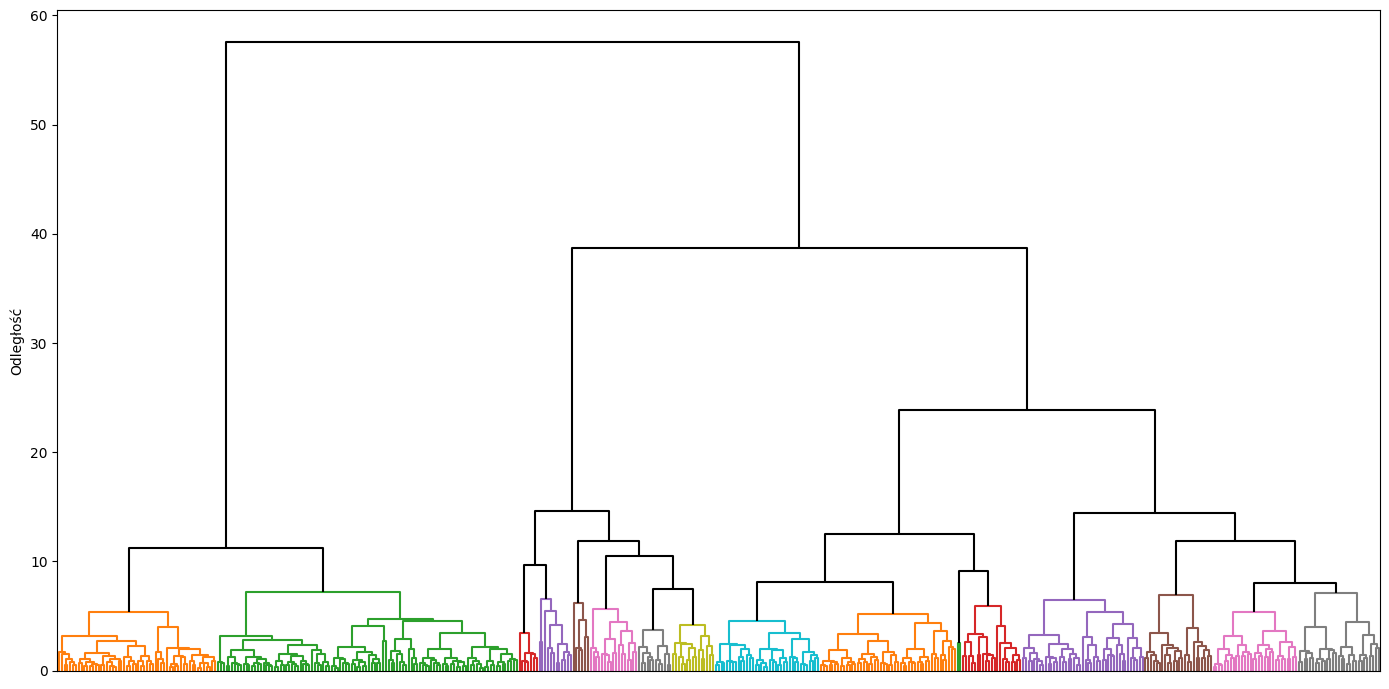

In [ ]:
### Zadanie 12
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

d_16_to_15 = linkage_comp[-15, 2]
d_17_to_16 = linkage_comp[-16, 2]
prog = (d_16_to_15 + d_17_to_16) / 2

cargs = {
    'color_threshold': prog,
    'above_threshold_color': 'black'
}

dendrogram(linkage_comp, ax=ax, truncate_mode='level', p=10, no_labels=True, **cargs)

ax.set_ylabel('Odległość')

plt.tight_layout()
plt.show()

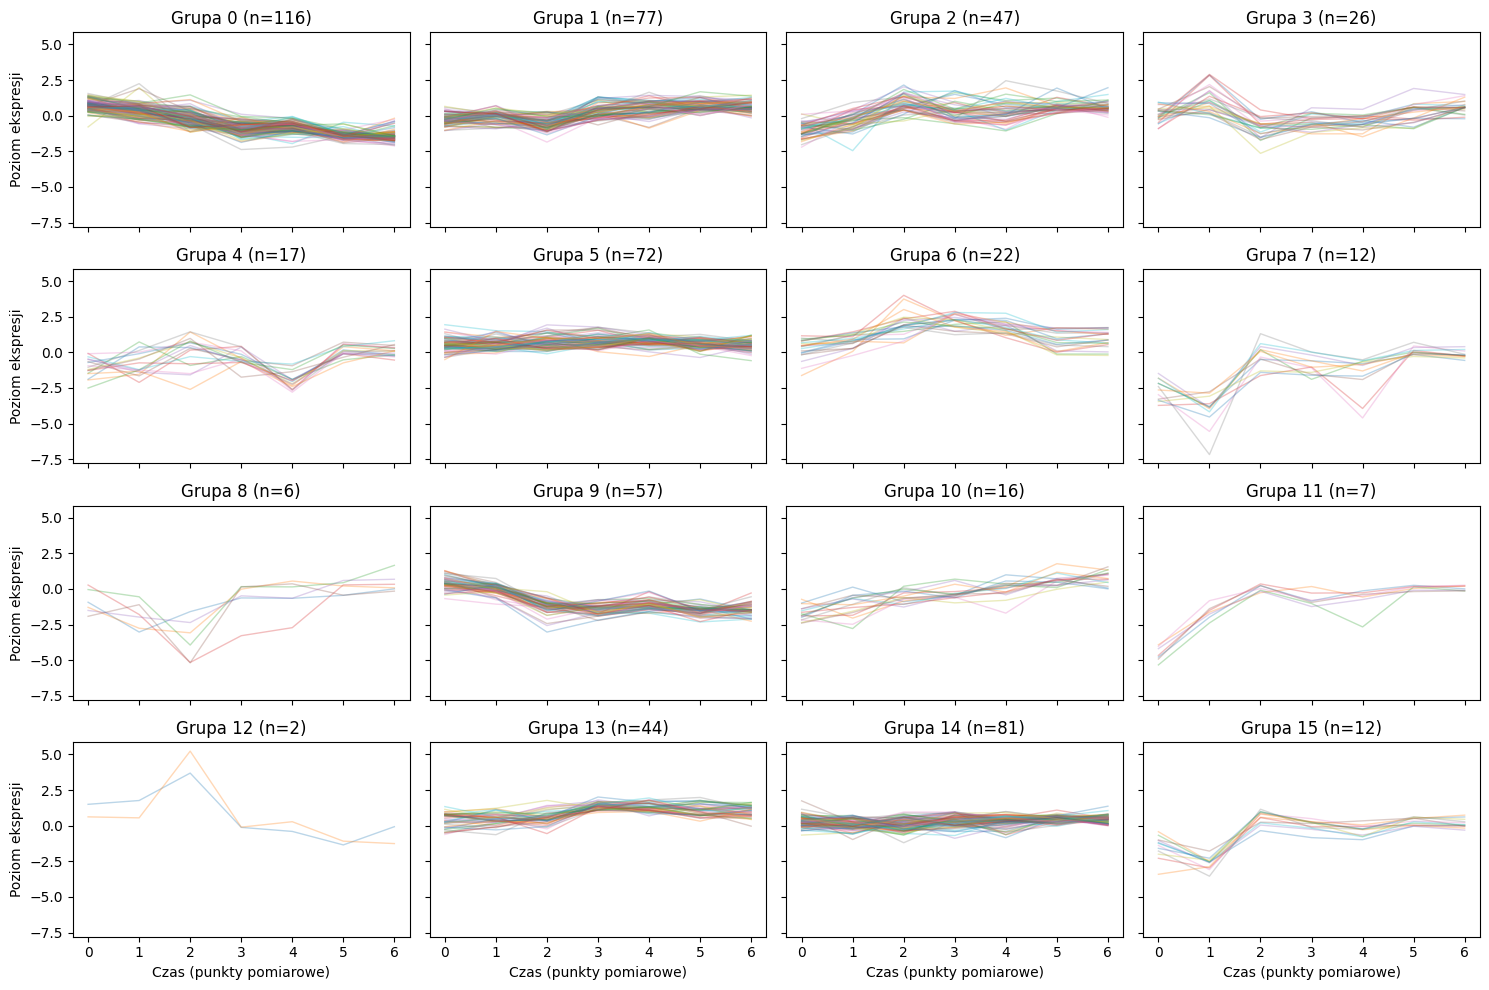

In [ ]:
### Zadanie 13
fig, axes = plt.subplots(4, 4, figsize=(15, 10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    grupy = dna_scaled[etykiety == i]

    for profil in grupy:
        ax.plot(profil, alpha=0.3, linewidth=1)

    ax.set_title(f'Grupa {i} (n={len(grupy)})')
    ax.set_xticks(range(7))

for ax in axes[-1, :]:
    ax.set_xlabel('Czas (punkty pomiarowe)')
for ax in axes[:, 0]:
    ax.set_ylabel('Poziom ekspresji')

plt.tight_layout()
plt.show()

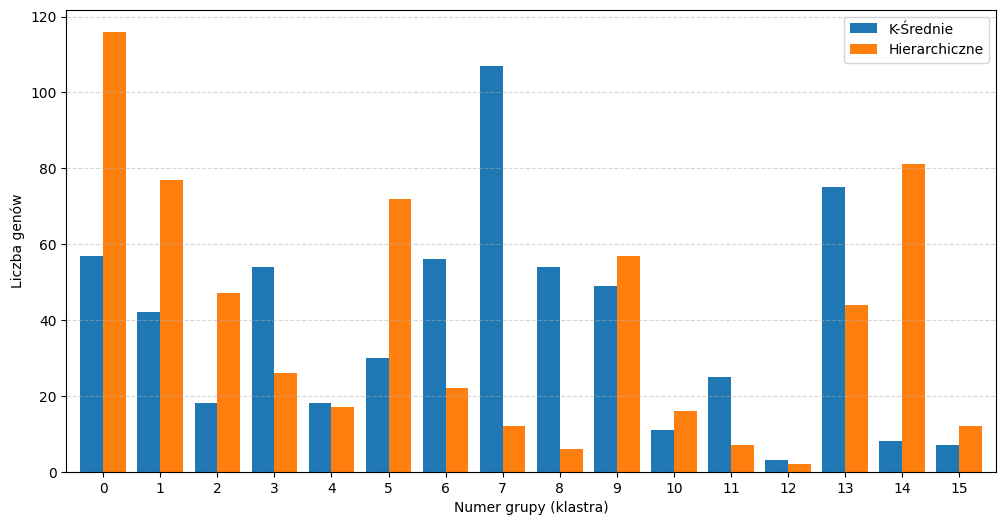

In [ ]:
### Zadanie 14
table = pd.DataFrame({
    'K-Średnie': kmeans.labels_,
    'Hierarchiczne': etykiety
})

table.apply(pd.Series.value_counts).plot(kind='bar', figsize=(12, 6), width=0.8)

plt.xlabel('Numer grupy (klastra)')
plt.ylabel('Liczba genów')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=0)
plt.show()

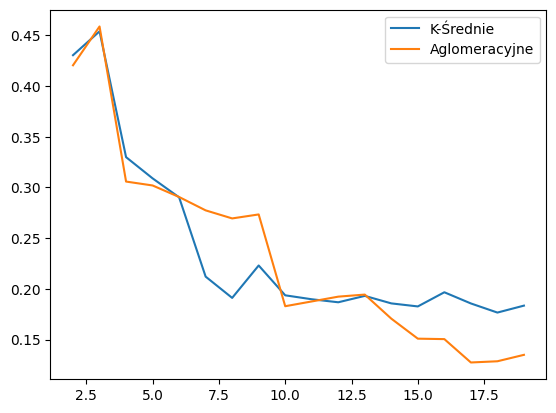

In [ ]:
### Zadanie 15
zakres = range(2, 20)

sil_km = [silhouette_score(dna_scaled, KMeans(k, n_init=10).fit_predict(dna_scaled)) for k in zakres]
sil_ag = [silhouette_score(dna_scaled, AgglomerativeClustering(k).fit_predict(dna_scaled)) for k in zakres]

plt.plot(zakres, sil_km, label='K-Średnie')
plt.plot(zakres, sil_ag, label='Aglomeracyjne')
plt.legend()
plt.show()

Nowy profil trafił do grupy K-Średnich nr: 7
Geny w tej grupie (107 szt.): YDL004W, YDL124W, YDR272W, YDR358W, YGR019W, YGR111W, YGR231C, YJL166W, YJR104C, YKL065C, YKL067W, YLR168C, YLR290C, YMR173W, YNL037C, YOR244W, YPL186C, NORF 7, YAL060W, YBR001C, YER096W, YER098W, YGR044C, YGR130C, YGR182C, YHR051W, YIL169C, YJL141C, YJR034W, YJR080C, YKL036C, YLR093C, YKR058W, YKR076W, YLR271W, YMR210W, YNL252C, YOL048C, YOL071W, YOR097C, YPL165C, YPR020W, YPR026W, NORF 8, NORF 54, YBL075C, YBL107C, YBR126C, YCL042W, YDR494W, YEL060C, YFR033C, YGL006W, YGL192W, YGL198W, YJR019C, YKL150W, YLR252W, YLR038C, YKR067W, YMR090W, YMR278W, YNL115C, YPL078C, YPL196W, YAL017W, YBL038W, YBL108W, YBR039W, YBR149W, YBR230C, YCL025C, YCR097W, YDL067C, YDR031W, YDR059C, YDR277C, YDR329C, YDR377W, YDR513W, YGL121C, YGL191W, YGL199C, YGR142W, YHL024W, YHR016C, YHR209W, YIL087C, YIL107C, YJL151C, YJR048W, YJR121W, YLR251W, YLR257W, YLR081W, YLR299W, YLR395C, YMR031C, YMR056C, YMR188C, YMR195W, YMR197C, YOL153C, 

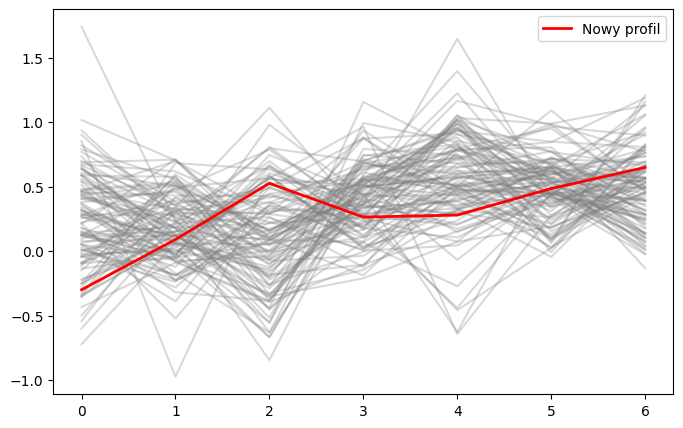

In [ ]:
x_nowy = np.array([[-0.2205, -0.0041, 0.3821, 0.3680, 0.4918, 1.6983, 1.9820]])
x_nowy_scaled = scaler.transform(x_nowy)

grupa = kmeans.predict(x_nowy_scaled)[0]
print(f"Nowy profil trafił do grupy K-Średnich nr: {grupa}")

geny_numpy = np.array(geny)
geny_w_grupie = geny_numpy[kmeans.labels_ == grupa]
print(f"Geny w tej grupie ({len(geny_w_grupie)} szt.): {', '.join(geny_w_grupie)}")

plt.figure(figsize=(8, 5))
plt.plot(dna_scaled[kmeans.labels_ == grupa].T, color='gray', alpha=0.3)
plt.plot(x_nowy_scaled[0], color='red', linewidth=2, label='Nowy profil')

plt.legend()
plt.show()